In [1]:
import datetime
import glob
import matplotlib.pyplot as plt
import numpy as np
import os

from astropy.table import QTable
import astropy.units as u
from astropy.coordinates import SkyCoord

%matplotlib widget

In [2]:
write_path = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/solve/'

In [3]:
img_table_solved = QTable.read(write_path + 'tabulated_solved.fits')

Post-process timestamps into datetime objects

In [4]:
t = []
t_not_nans = []
for i in range(len(img_table_solved)):
    if ~np.isnan(img_table_solved['TIMESTAMP'][i]):
        t.append(
            datetime.datetime.fromtimestamp(
                img_table_solved['TIMESTAMP'][i].value,
                datetime.timezone(datetime.timedelta(hours=0))
            )
        )
        t_not_nans.append(True)
    else:
        t.append(np.nan)
        t_not_nans.append(False)
t = np.array(t)

Analyze autofocus run results

In [5]:
# af_files = []
# af_files += sorted(glob.glob(os.path.join(write_path, '..', 'auto*2025-10-01_1[8-9]*.txt')))
# af_files += sorted(glob.glob(os.path.join(write_path, '..', 'auto*2025-10-01_2[0-3]*.txt')))
# af_files += sorted(glob.glob(os.path.join(write_path, '..', 'auto*2025-10-02_00*.txt')))
af_files = sorted(glob.glob(os.path.join(write_path, '..', 'auto*2025-10-0[1-2]*.txt')))

af_times = []
for file in af_files:
    b = os.path.splitext(os.path.basename(file))[0]
    parts = b.split('_')
    date, time = parts[-2:]
    af_times.append(datetime.datetime.fromisoformat(date + 'T' + time.replace('-', ':')))
[print(af_time) for af_time in af_times];

2025-10-01 11:00:33
2025-10-01 15:02:44
2025-10-01 19:04:55
2025-10-01 23:07:07
2025-10-02 03:09:17
2025-10-02 07:11:28
2025-10-02 11:13:39


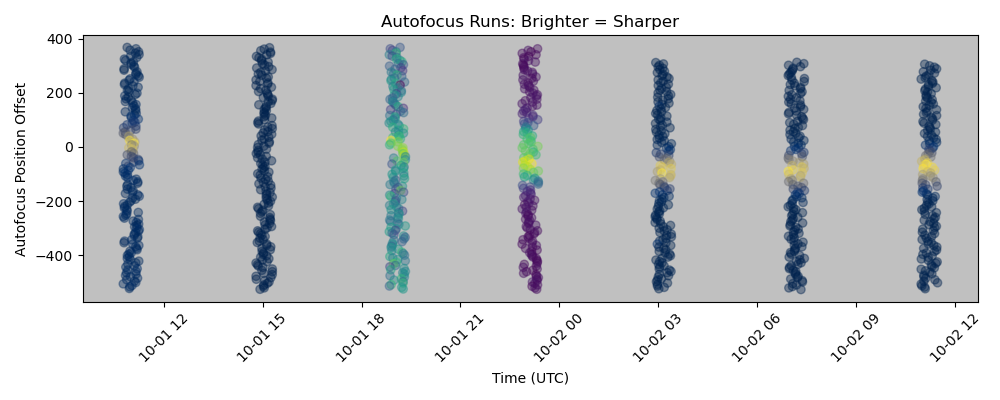

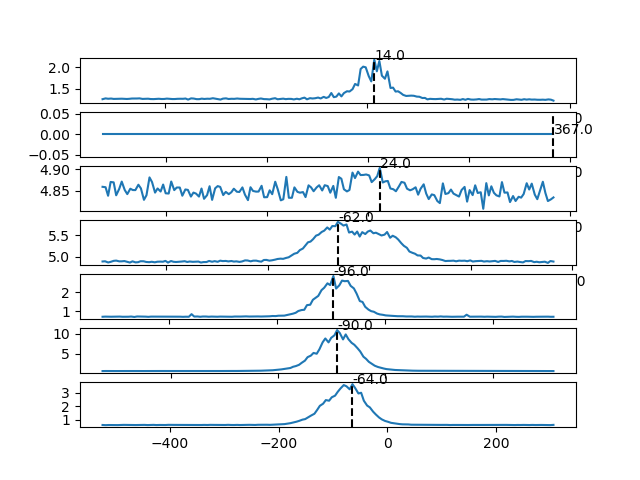

In [6]:
fig, ax = plt.subplots(figsize=(10,4))
daytime_start = datetime.datetime.fromisoformat('2025-10-01T16:00:00')
daytime_end = datetime.datetime.fromisoformat('2025-10-02T01:00:00')
for i, af_file in enumerate(af_files):
    sharpness, focus_pos = np.genfromtxt(af_file, unpack=True)
    # print(sharpness, focus_pos)
    judder = np.array([datetime.timedelta(hours=hr) for hr in np.random.uniform(-.25, .25, size=len(focus_pos))]) 
    # print('judder', judder)
    if daytime_start < af_times[i] < daytime_end:
        cmap = 'viridis'
    else:
        cmap = 'cividis'
    ax.scatter(np.array([af_times[i],] * len(focus_pos)) + judder, focus_pos, c=sharpness, cmap=cmap, alpha=0.4)

f, a = plt.subplots(nrows=len(af_files))
for i, af_file in enumerate(af_files):
    sharpness, focus_pos = np.genfromtxt(af_file, unpack=True)
    a[i].plot(focus_pos, sharpness)
    a[i].axvline(focus_pos[np.argmax(sharpness)], linestyle='--', color='k')
    a[i].text(focus_pos[np.argmax(sharpness)], sharpness[np.argmax(sharpness)], str(focus_pos[np.argmax(sharpness)]))
ax.xaxis.set_tick_params(rotation=45)
ax.set_facecolor('silver')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Autofocus Position Offset')
ax.set_title('Autofocus Runs: Brighter = Sharper')
fig.tight_layout()

Break down results using the "nominal" exposure parameters: number of stars matched from the catalog, time evoluation of focus offsets, and dependence of number of stars matched on focus position.

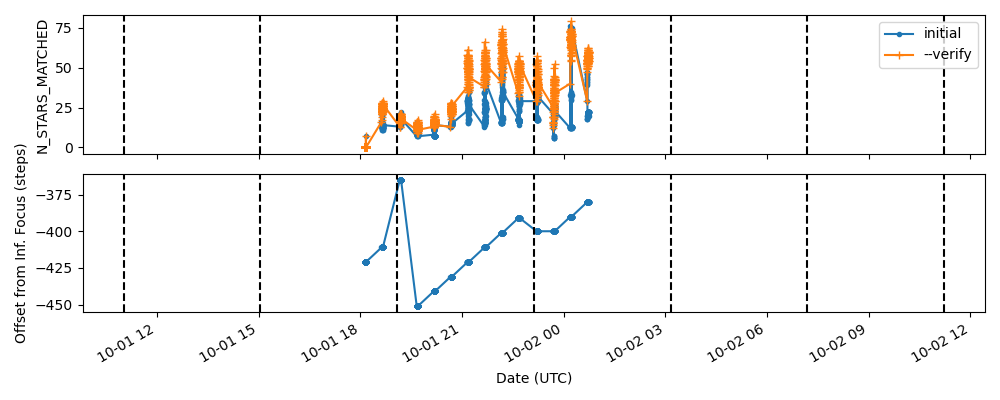

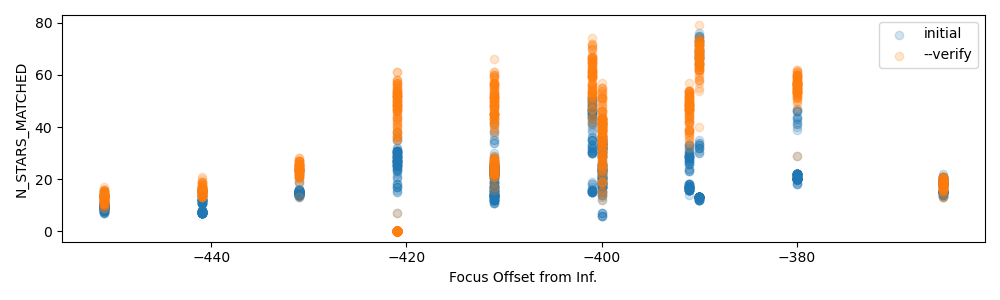

In [7]:
default_gain = (abs(img_table_solved['GAINFACT'] - 1.0) < 1e-3)
default_exp = (abs(img_table_solved['EXPTIME'] - 0.1 * u.s) < 1e-3 * u.s)
daytime_float = []
for fname in img_table_solved['FILES']:
    if (
        ('10-01_18' in fname)
        or ('10-01_19' in fname)
        or ('10-01_20' in fname)
        or ('10-01_21' in fname)
        or ('10-01_22' in fname)
        or ('10-01_23' in fname)
        or ('10-02_00' in fname)
    ):
        daytime_float.append(True)
        # print(fname)
    else:
        daytime_float.append(False)
daytime_float = np.array(daytime_float)
# [print(file) for file in img_table_solved[default_gain & default_exp & daytime_float]['FILES']];

fig, ax = plt.subplots(figsize=(10,4), nrows=2, sharex=True)
ax[0].plot(
    # img_table_solved[default_gain & default_exp & daytime_float]['TIMESTAMP'],
    t[t_not_nans & default_gain & default_exp & daytime_float],
    img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_MATCHED'],
    marker='.',
    label='initial'
)
ax[0].plot(
    # img_table_solved[default_gain & default_exp & daytime_float]['TIMESTAMP'],
    t[t_not_nans & default_gain & default_exp & daytime_float],
    img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_REMATCHED'],
    marker='+',
    label='--verify'
)
[ax[0].axvline(af_time, color='k', linestyle='--') for af_time in af_times]
ax[0].set_ylabel('N_STARS_MATCHED')
ax[0].legend()

ax[1].plot(
    # img_table_solved[default_gain & default_exp & daytime_float]['TIMESTAMP'],
    t[t_not_nans & default_gain & default_exp & daytime_float],
    img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['FOCUS'] - img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['FOCUSMAX'],
    marker='.'
)
[ax[1].axvline(af_time, color='k', linestyle='--') for af_time in af_times]
ax[1].set_ylabel('Offset from Inf. Focus (steps)')
ax[1].set_xlabel('Date (UTC)')
fig.autofmt_xdate()
fig.tight_layout()

fig, ax = plt.subplots(figsize=(10,3))
ax.scatter(
    img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['FOCUS'] - img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['FOCUSMAX'],
    img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_MATCHED'],
    alpha=0.2,
    label='initial'
)
ax.scatter(
    img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['FOCUS'] - img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['FOCUSMAX'],
    img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_REMATCHED'],
    alpha=0.2,
    label='--verify'
)
ax.legend()
ax.set_xlabel('Focus Offset from Inf.')
ax.set_ylabel('N_STARS_MATCHED')
fig.tight_layout()

In [27]:
idx = np.argsort(img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_REMATCHED'])[::-1]
img_table_solved[t_not_nans & default_gain & default_exp & daytime_float][idx].pprint_all()

FOCUSMIN FOCUS FOCUSMAX GAINFACT  EXPTIME    UTC-SEC          UTC-USEC       CCDTEMP                           FILES                           SOLVE_ATTEMPTED SOLVED  FILESIZE      TIMESTAMP             RA                DEC            ORIENTATION        SCALE     N_STARS_FOUND N_STARS_MATCHED         RMSE         BKG_MED      BKG_MEAN      N_STARS_REMATCHED
                                     s          s                s            deg_C                                                                                                      s                deg                deg                deg         arcsec / pix                                      arcsec                                                    
-------- ----- -------- -------- --------- ------------ -------------------- ------- --------------------------------------------------------- --------------- ------ ---------- ----------------- ------------------ ------------------ ------------------ ------------ -------------

With base gain, 0.1s exposure, median 19.0 +12.0/-7.0 stars matched per image.
With base gain, 0.1s exposure, median 37.0 +20.0/-22.0 stars matched with --verify per image.


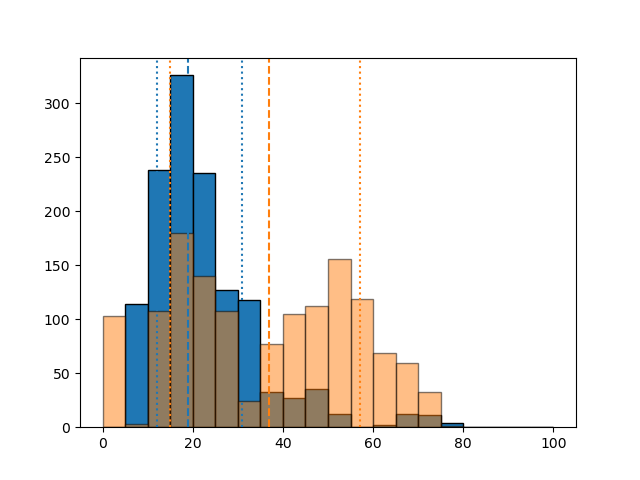

In [8]:
fig, ax = plt.subplots()

binedges = np.arange(0, 105, 5)

matched_med = np.nanmedian(img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_MATCHED'])
ax.hist(img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_MATCHED'], bins=binedges, edgecolor='k')
pct = np.nanpercentile(img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_MATCHED'], (16,84))
ax.axvline(matched_med, color='C0', linestyle='--')
ax.axvline(pct[0], color='C0', linestyle=':')
ax.axvline(pct[1], color='C0', linestyle=':')
print('With base gain, 0.1s exposure, median', matched_med, f'+{np.abs(pct[1] - matched_med)}/-{np.abs(matched_med - pct[0])}', 'stars matched per image.')

matched_med = np.nanmedian(img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_REMATCHED'])
ax.hist(img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_REMATCHED'], bins=binedges, edgecolor='k', alpha=0.5)
pct = np.nanpercentile(img_table_solved[t_not_nans & default_gain & default_exp & daytime_float]['N_STARS_REMATCHED'], (16,84))
ax.axvline(matched_med, color='C1', linestyle='--')
ax.axvline(pct[0], color='C1', linestyle=':')
ax.axvline(pct[1], color='C1', linestyle=':')
print('With base gain, 0.1s exposure, median', matched_med, f'+{np.abs(pct[1] - matched_med)}/-{np.abs(matched_med - pct[0])}', 'stars matched with --verify per image.')

Breakdown of successful solution rate across exposure parameter space

1 0.05 s [1. 1. 1. ... 1. 1. 1.] [0.04999641 0.04999641 0.04999641 ... 0.04999641 0.04999641 0.04999641] s
2 0.05 s [2. 2. 2. ... 2. 2. 2.] [0.04999641 0.04999641 0.04999641 ... 0.04999641 0.04999641 0.04999641] s
3 0.05 s [3. 3. 3. ... 3. 3. 3.] [0.04999641 0.04999641 0.04999641 ... 0.04999641 0.04999641 0.04999641] s
4 0.05 s [4. 4. 4. ... 4. 4. 4.] [0.04999641 0.04999641 0.04999641 ... 0.04999641 0.04999641 0.04999641] s
1 0.1 s [1. 1. 1. ... 1. 1. 1.] [0.1000048 0.1000048 0.1000048 ... 0.1000048 0.1000048 0.1000048] s
2 0.1 s [2. 2. 2. ... 2. 2. 2.] [0.1000048 0.1000048 0.1000048 ... 0.1000048 0.1000048 0.1000048] s
3 0.1 s [3. 3. 3. ... 3. 3. 3.] [0.1000048 0.1000048 0.1000048 ... 0.1000048 0.1000048 0.1000048] s
4 0.1 s [4. 4. 4. ... 4. 4. 4.] [0.1000048 0.1000048 0.1000048 ... 0.1000048 0.1000048 0.1000048] s
1 0.2 s [1. 1. 1. ... 1. 1. 1.] [0.2000071 0.2000071 0.2000071 ... 0.2000071 0.2000071 0.2000071] s
2 0.2 s [2. 2. 2. ... 2. 2. 2.] [0.2000071 0.2000071 0.2000071 ... 0.200

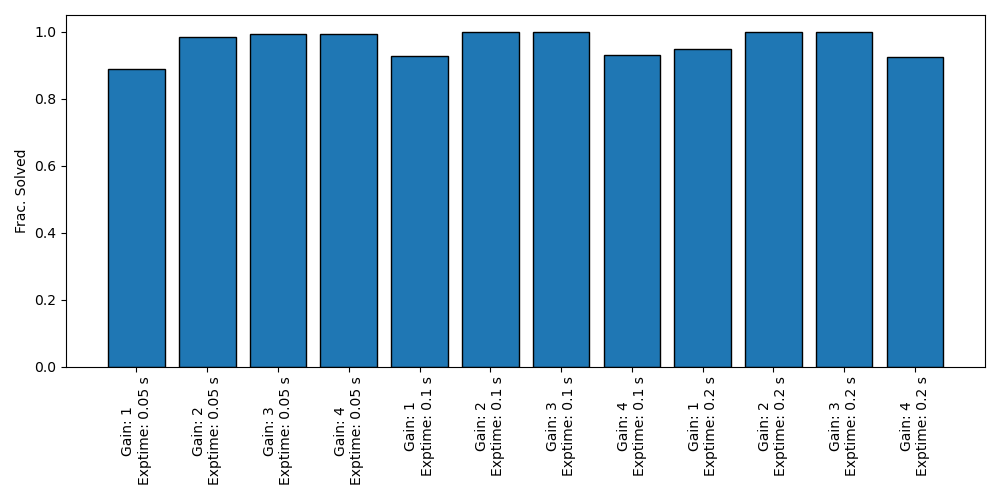

In [9]:
fig, ax = plt.subplots(figsize=(10,5))

float_time = datetime.datetime.fromisoformat('2025-10-01T19:00:00.0000Z').timestamp() * u.s
daytime_end = float_time + 8 * u.hr

tol = 1e-3
i = 0
labels = []
for exptime in np.array([0.05, 0.1, 0.2]) * u.s:
    for gain in range(1,5):
        pop = (
            daytime_float &
            (abs(img_table_solved['GAINFACT'] - gain) < tol) &
            (abs(img_table_solved['EXPTIME'] - exptime) < (tol * exptime.unit))
        )
        print(gain, exptime, img_table_solved['GAINFACT'][pop], img_table_solved['EXPTIME'][pop])
        ax.bar(i, np.nansum(img_table_solved['SOLVED'][pop]) / np.nansum(img_table_solved['SOLVE_ATTEMPTED'][pop]), color='C0', edgecolor='k')
        i += 1
        labels.append(f'Gain: {gain}\nExptime: {exptime}')
ax.set_ylabel('Frac. Solved')
ax.set_xticks(range(i))
ax.set_xticklabels(labels, rotation=90)
fig.tight_layout()

Breakdown of number of candidate stars sent to solver and successfully matched vs. exposure parameter space.

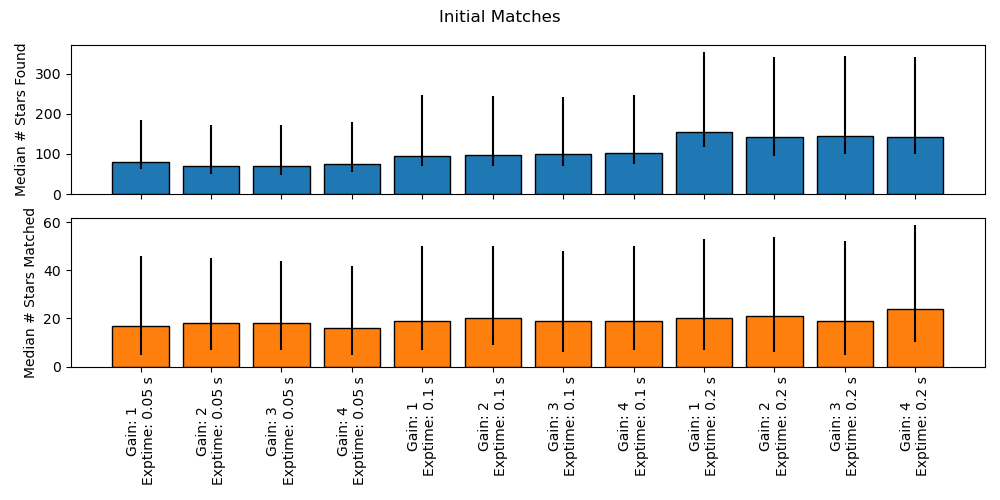

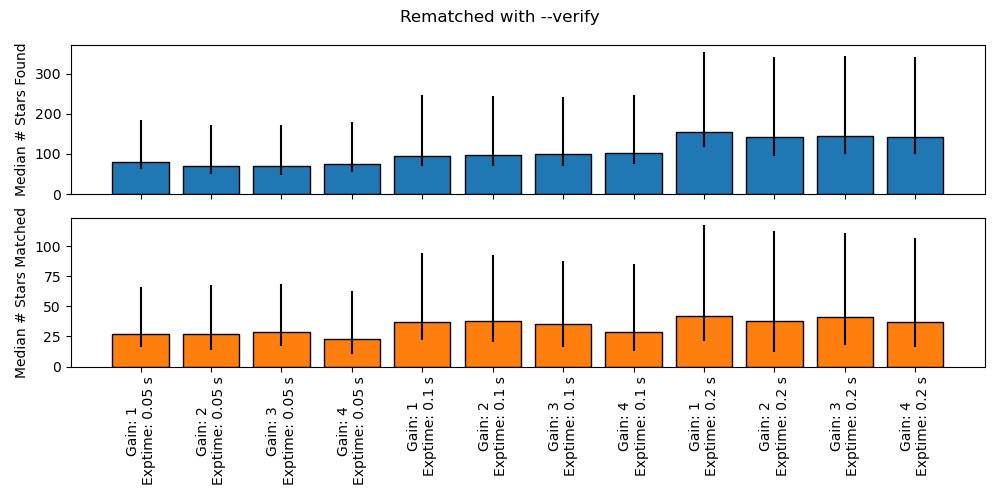

In [10]:
fig, ax = plt.subplots(figsize=(10,5), nrows=2, sharex=True)

tol = 1e-3
i = 0
labels = []
for exptime in np.array([0.05, 0.1, 0.2]) * u.s:
    for gain in range(1,5):
        pop = (
            daytime_float &
            (abs(img_table_solved['GAINFACT'] - gain) < tol) &
            (abs(img_table_solved['EXPTIME'] - exptime) < (tol * exptime.unit))
        )
        # print(gain, exptime, img_table_solved['GAINFACT'][pop], img_table_solved['EXPTIME'][pop])
        pct = np.nanpercentile(img_table_solved['N_STARS_FOUND'][pop], (16, 50, 84))
        ax[0].bar(i, pct[1], yerr=[[pct[0],], [pct[-1],]], edgecolor='k', facecolor='C0')
        pct = np.nanpercentile(img_table_solved['N_STARS_MATCHED'][pop], (16, 50, 84))
        ax[1].bar(i, pct[1], yerr=[[pct[0],], [pct[-1],]], edgecolor='k', facecolor='C1')
        i += 1
        labels.append(f'Gain: {gain}\nExptime: {exptime}')
ax[0].set_ylabel('Median # Stars Found')
ax[1].set_ylabel('Median # Stars Matched')
ax[1].set_xticks(range(i))
ax[1].set_xticklabels(labels, rotation=90)
fig.suptitle('Initial Matches')
fig.tight_layout()


fig, ax = plt.subplots(figsize=(10,5), nrows=2, sharex=True)

i = 0
labels = []
for exptime in np.array([0.05, 0.1, 0.2]) * u.s:
    for gain in range(1,5):
        pop = (
            daytime_float &
            (abs(img_table_solved['GAINFACT'] - gain) < tol) &
            (abs(img_table_solved['EXPTIME'] - exptime) < (tol * exptime.unit))
        )
        # print(gain, exptime, img_table_solved['GAINFACT'][pop], img_table_solved['EXPTIME'][pop])
        pct = np.nanpercentile(img_table_solved['N_STARS_FOUND'][pop], (16, 50, 84))
        ax[0].bar(i, pct[1], yerr=[[pct[0],], [pct[-1],]], edgecolor='k', facecolor='C0')
        pct = np.nanpercentile(img_table_solved['N_STARS_REMATCHED'][pop], (16, 50, 84))
        ax[1].bar(i, pct[1], yerr=[[pct[0],], [pct[-1],]], edgecolor='k', facecolor='C1')
        i += 1
        labels.append(f'Gain: {gain}\nExptime: {exptime}')
ax[0].set_ylabel('Median # Stars Found')
ax[1].set_ylabel('Median # Stars Matched')
ax[1].set_xticks(range(i))
ax[1].set_xticklabels(labels, rotation=90)
fig.suptitle('Rematched with --verify')
fig.tight_layout()

Time evolution of solved parameters over the run

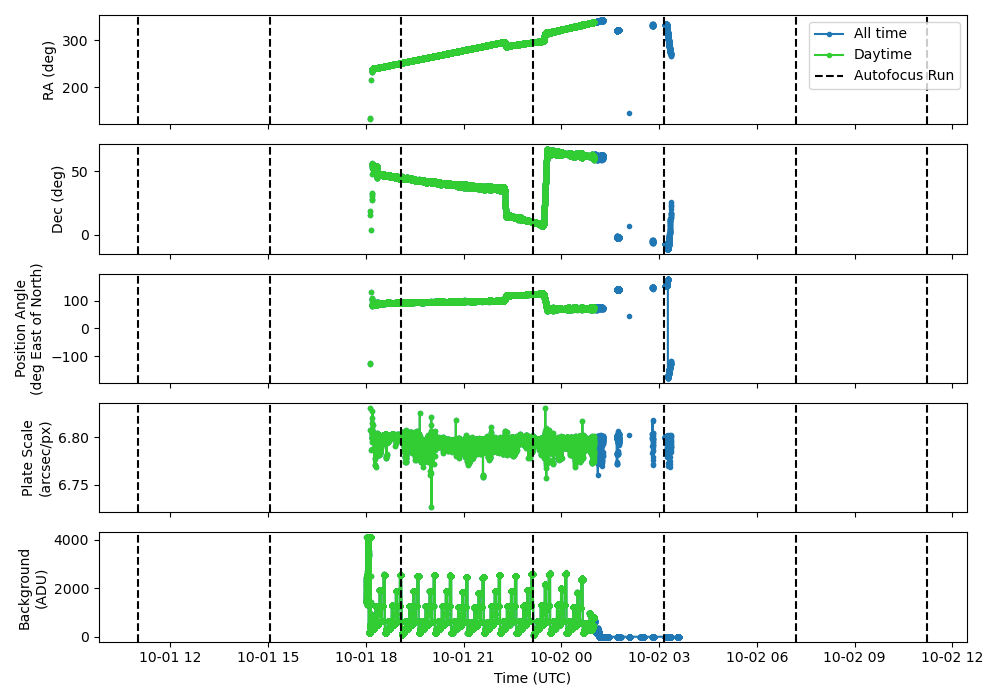

In [11]:
fig, ax = plt.subplots(figsize=(10,7), nrows=5, sharex=True)
ax[0].plot(t[t_not_nans], img_table_solved['RA'][t_not_nans], marker='.')
ax[0].plot(t[t_not_nans & daytime_float], img_table_solved['RA'][t_not_nans & daytime_float], marker='.', color='limegreen')
[ax[0].axvline(af_time, color='k', linestyle='--') for af_time in af_times]
ax[0].legend(['All time', 'Daytime', 'Autofocus Run'])
ax[0].set_ylabel('RA (deg)')

ax[1].plot(t[t_not_nans], img_table_solved['DEC'][t_not_nans], marker='.')
ax[1].plot(t[t_not_nans & daytime_float], img_table_solved['DEC'][t_not_nans & daytime_float], marker='.', color='limegreen')
[ax[1].axvline(af_time, color='k', linestyle='--') for af_time in af_times]
ax[1].set_ylabel('Dec (deg)')

ax[2].plot(t[t_not_nans], img_table_solved['ORIENTATION'][t_not_nans], marker='.')
ax[2].plot(t[t_not_nans & daytime_float], img_table_solved['ORIENTATION'][t_not_nans & daytime_float], marker='.', color='limegreen')
[ax[2].axvline(af_time, color='k', linestyle='--') for af_time in af_times]
ax[2].set_ylabel('Position Angle\n(deg East of North)')

ax[3].plot(t[t_not_nans], img_table_solved['SCALE'][t_not_nans], marker='.')
ax[3].plot(t[t_not_nans & daytime_float], img_table_solved['SCALE'][t_not_nans & daytime_float], marker='.', color='limegreen')
[ax[3].axvline(af_time, color='k', linestyle='--') for af_time in af_times]
ax[3].set_ylabel('Plate Scale\n(arcsec/px)')

ax[4].plot(t[t_not_nans], img_table_solved['BKG_MEAN'][t_not_nans], marker='.')
ax[4].plot(t[t_not_nans & daytime_float], img_table_solved['BKG_MEAN'][t_not_nans & daytime_float], marker='.', color='limegreen')
[ax[4].axvline(af_time, color='k', linestyle='--') for af_time in af_times]
ax[4].set_ylabel('Background\n(ADU)')
ax[4].set_xlabel('Time (UTC)')

fig.tight_layout()

Time evolution of mean background counts (ADU)

Text(0, 0.5, 'ADU')

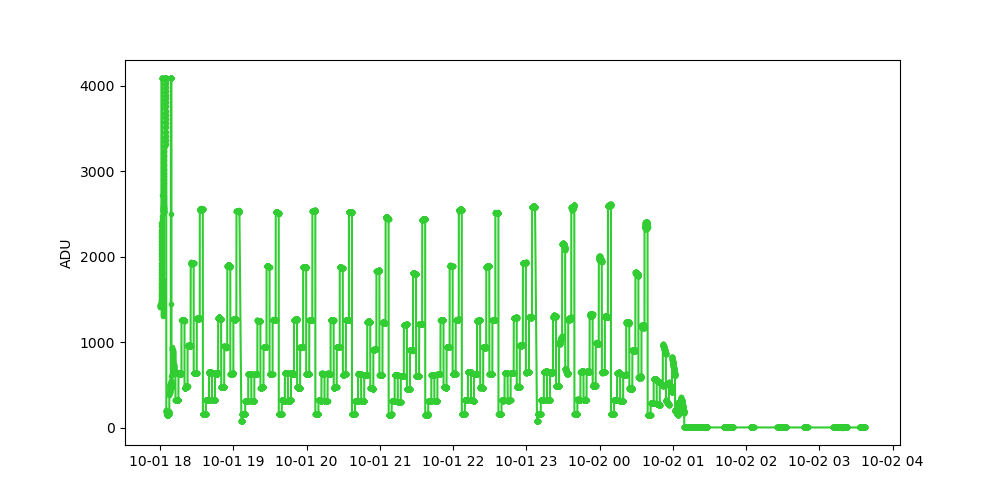

In [12]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(t[t_not_nans], img_table_solved['BKG_MEAN'][t_not_nans], marker='.', color='limegreen')
ax.set_ylabel('ADU')

Correlation of exposure time vs. background counts (ADU)

Text(0, 0.5, 'Background (ADU)')

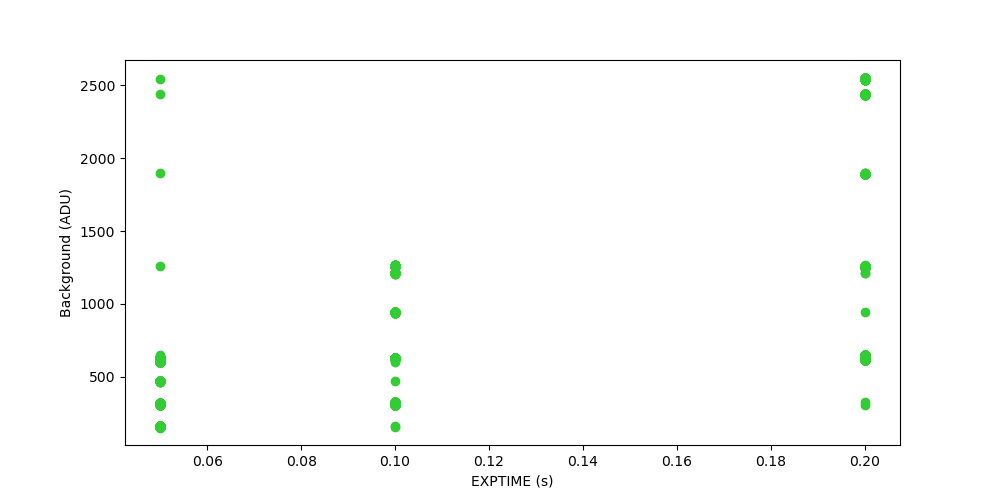

In [13]:
fig, ax = plt.subplots(figsize=(10,5))
# ax.scatter(img_table_solved['EXPTIME'], img_table_solved['BKG_MEAN'])
e = img_table_solved['EXPTIME'][daytime_float]
b = img_table_solved['BKG_MEAN'][daytime_float]
ax.scatter(
    e[len(e)//2:len(e)//2 + 2000],
    b[len(e)//2:len(e)//2 + 2000],
    color='limegreen'
)
ax.set_xlabel('EXPTIME (s)')
ax.set_ylabel('Background (ADU)')
# ax.set_yscale('log')

Sky coverage of solutions, colored by uncertainty

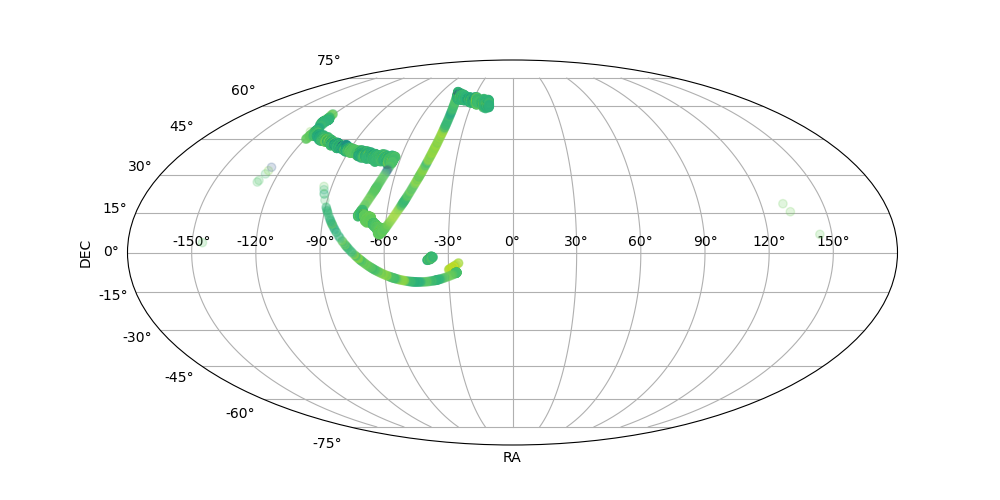

In [14]:
fig, ax = plt.subplots(figsize=(10,5), subplot_kw=dict(projection='mollweide'))
not_nans = ~np.isnan(img_table_solved['RA'])
ra = img_table_solved['RA'][not_nans].to(u.rad)
dec = img_table_solved['DEC'][not_nans].to(u.rad),
ra[ra > np.pi * u.rad] -= 2 * np.pi * u.rad
ax.scatter(
    ra,
    dec,
    c=np.log10(img_table_solved['RMSE'][not_nans].value),
    alpha=0.2
)
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
ax.grid()
ax.set_axisbelow(True)

Sky coverage of solutions, colored by number of stars matched. Daytime and nightttime.

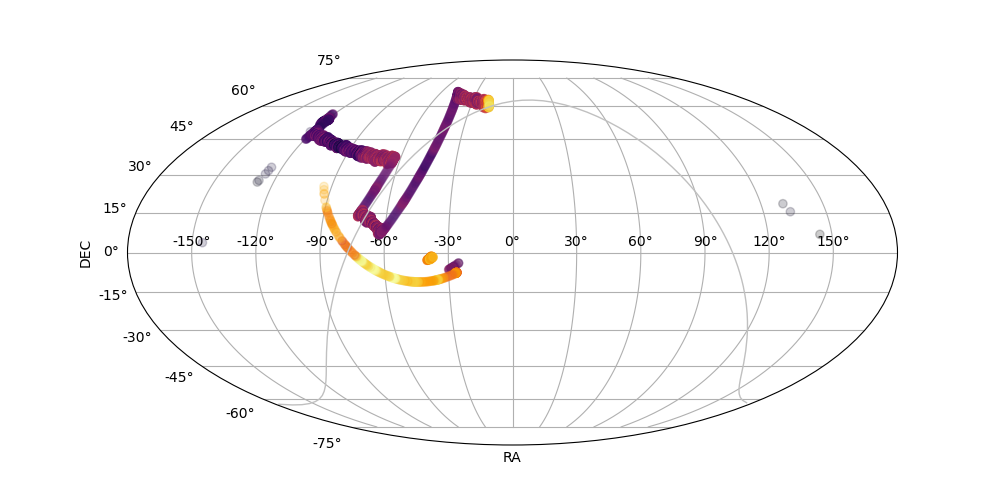

In [15]:
fig, ax = plt.subplots(figsize=(10,5), subplot_kw=dict(projection='mollweide'))
not_nans = ~np.isnan(img_table_solved['RA'])
ra = img_table_solved['RA'][not_nans].to(u.rad)
dec = img_table_solved['DEC'][not_nans].to(u.rad),
ra[ra > np.pi * u.rad] -= 2 * np.pi * u.rad
ax.scatter(
    ra,
    dec,
    c=np.log10(img_table_solved['N_STARS_REMATCHED'][not_nans].value),
    alpha=0.2,
    cmap='inferno'
)
l = np.linspace(0, 360, 100) * u.deg
b = np.zeros_like(l)
gal_plane = SkyCoord(l=l, b=b, frame='galactic')
gal_radec = gal_plane.icrs
ra_rad = gal_radec.ra.wrap_at(180 * u.degree).radian
idx = np.argsort(ra_rad)
dec_rad = gal_radec.dec.radian
ax.plot(ra_rad[idx], dec_rad[idx], linewidth=1, label='Galactic Plane', color='silver')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
ax.grid()
ax.set_axisbelow(True)

As above, nighttime only

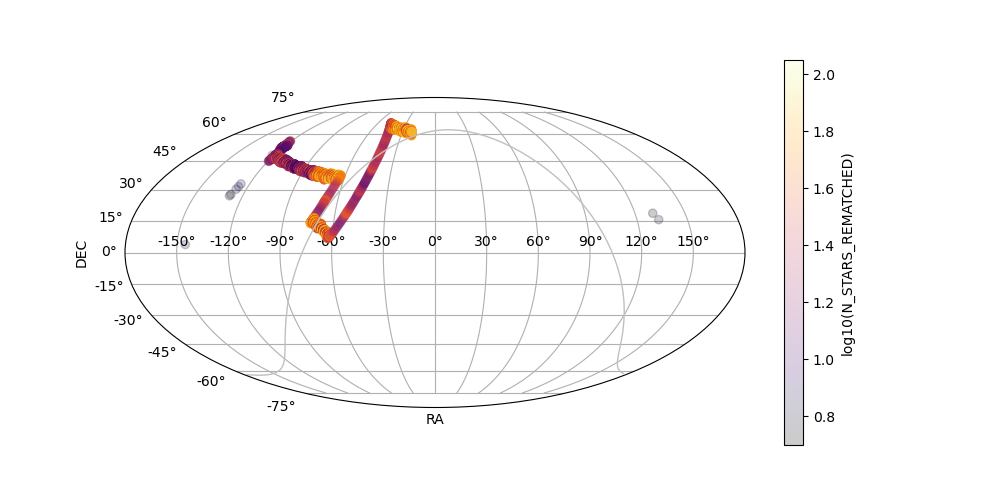

In [16]:
fig, ax = plt.subplots(figsize=(10,5), subplot_kw=dict(projection='mollweide'))
not_nans = ~np.isnan(img_table_solved[daytime_float]['RA'])
ra = img_table_solved[daytime_float]['RA'][not_nans].to(u.rad)
dec = img_table_solved[daytime_float]['DEC'][not_nans].to(u.rad),
ra[ra > np.pi * u.rad] -= 2 * np.pi * u.rad
im = ax.scatter(
    ra,
    dec,
    c=np.log10(img_table_solved[daytime_float]['N_STARS_REMATCHED'][not_nans].value),
    alpha=0.2,
    cmap='inferno'
)
fig.colorbar(im, ax=ax, label='log10(N_STARS_REMATCHED)')
l = np.linspace(0, 360, 100) * u.deg
b = np.zeros_like(l)
gal_plane = SkyCoord(l=l, b=b, frame='galactic')
gal_radec = gal_plane.icrs
ra_rad = gal_radec.ra.wrap_at(180 * u.degree).radian
idx = np.argsort(ra_rad)
dec_rad = gal_radec.dec.radian
ax.plot(ra_rad[idx], dec_rad[idx], linewidth=1, label='Galactic Plane', color='silver')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
ax.grid()
ax.set_axisbelow(True)

Time evolution of solution RMSE

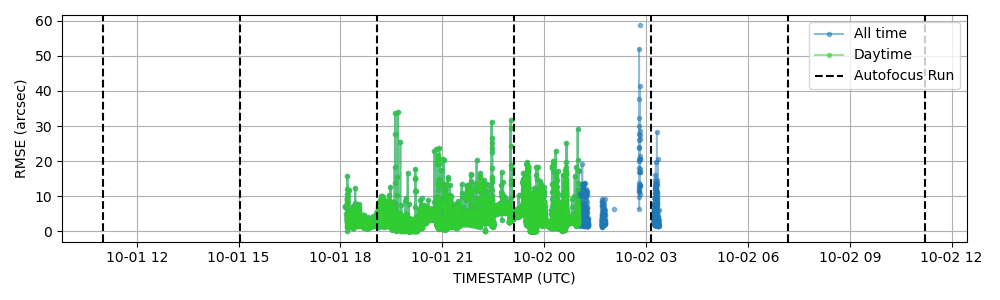

In [17]:
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(t[t_not_nans], img_table_solved['RMSE'][t_not_nans], marker='.', alpha=0.5)
ax.plot(t[t_not_nans & daytime_float], img_table_solved['RMSE'][t_not_nans & daytime_float], marker='.', color='limegreen', alpha=0.5)
[ax.axvline(af_time, color='k', linestyle='--') for af_time in af_times]
ax.set_xlabel('TIMESTAMP (UTC)')
ax.set_ylabel('RMSE (arcsec)')
ax.grid()
ax.legend(['All time', 'Daytime', 'Autofocus Run'])
fig.tight_layout()

Breakdown of RMSE per exposure parameter combination

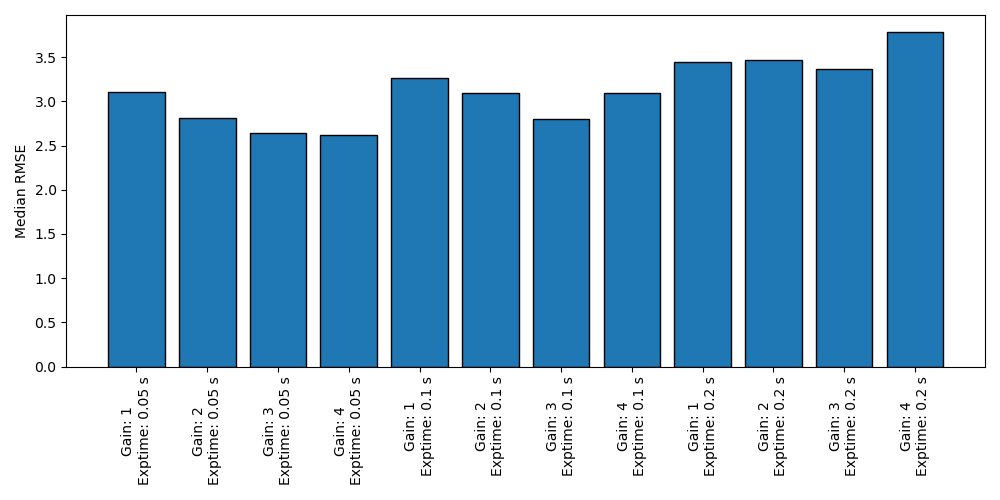

In [18]:
fig, ax = plt.subplots(figsize=(10,5))

tol = 1e-3
i = 0
labels = []
for exptime in np.array([0.05, 0.1, 0.2]) * u.s:
    for gain in range(1,5):
        pop = (
            daytime_float &
            (abs(img_table_solved['GAINFACT'] - gain) < tol) &
            (abs(img_table_solved['EXPTIME'] - exptime) < (tol * exptime.unit))
        )
        ax.bar(i, np.nanmedian(img_table_solved['RMSE'][pop]), color='C0', edgecolor='k')
        i += 1
        labels.append(f'Gain: {gain}\nExptime: {exptime}')
ax.set_ylabel('Median RMSE')
ax.set_xticks(range(i))
ax.set_xticklabels(labels, rotation=90)
fig.tight_layout()

Correlation of successful star matches vs. RMSE, and exposure, gain, and focus position vs. RMSE

/home/evanmayer/miniconda3/envs/astr-new/lib/python3.11/site-packages/seaborn/axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


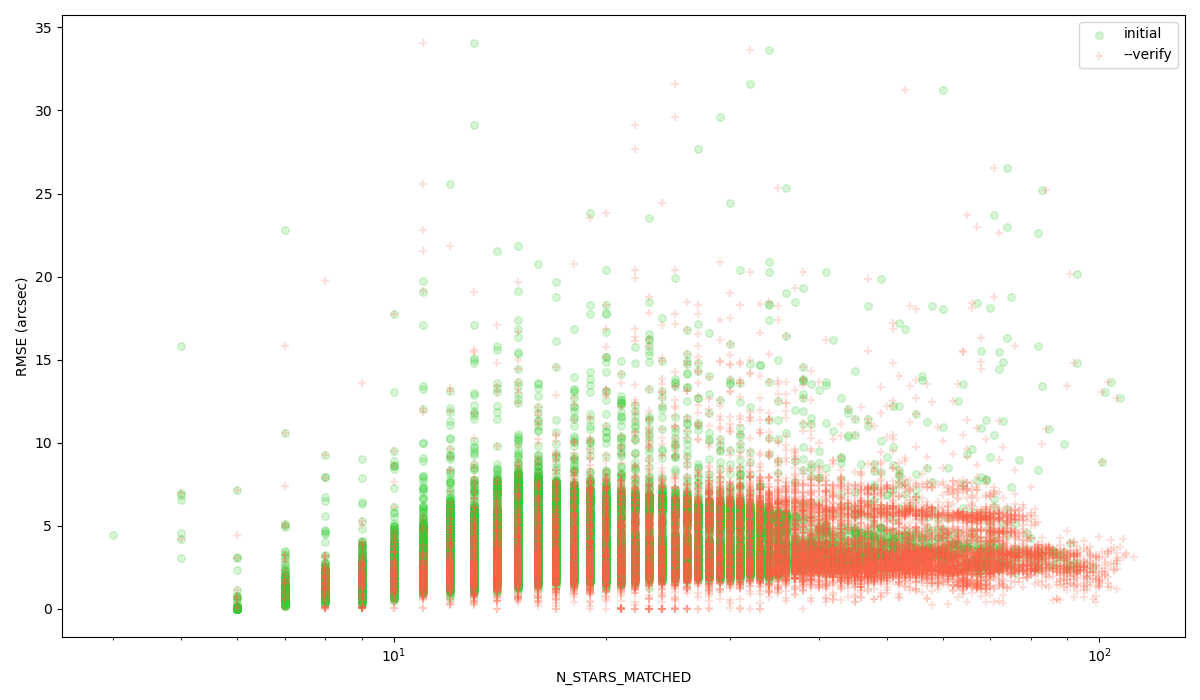

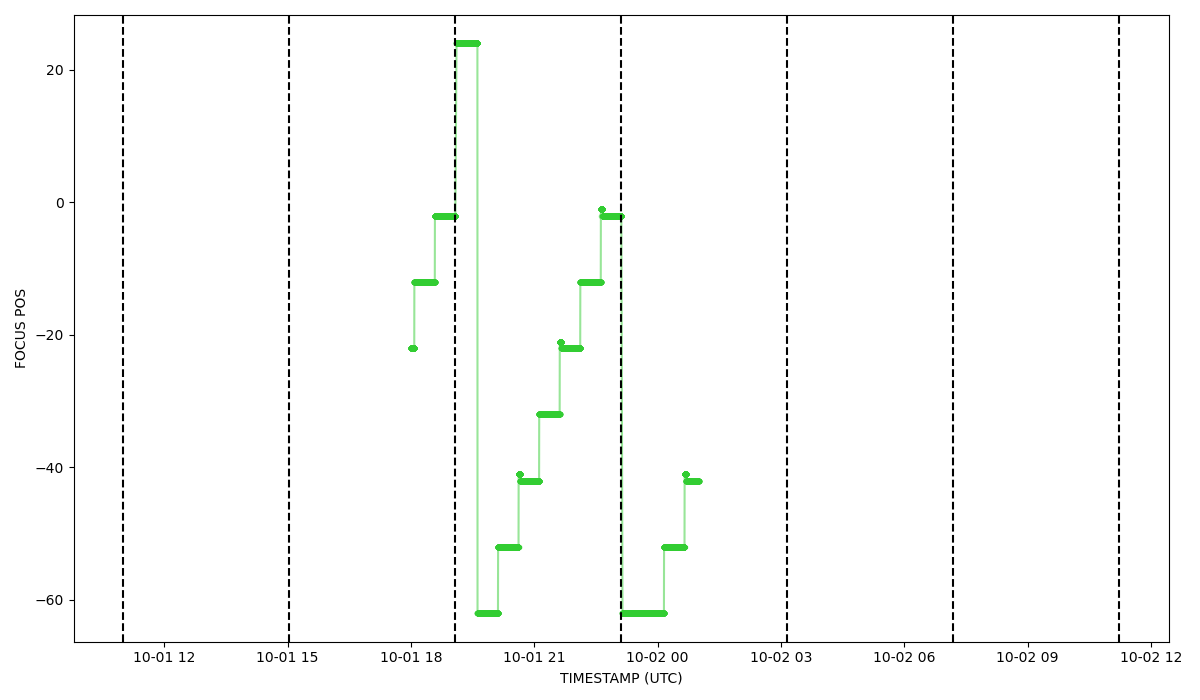

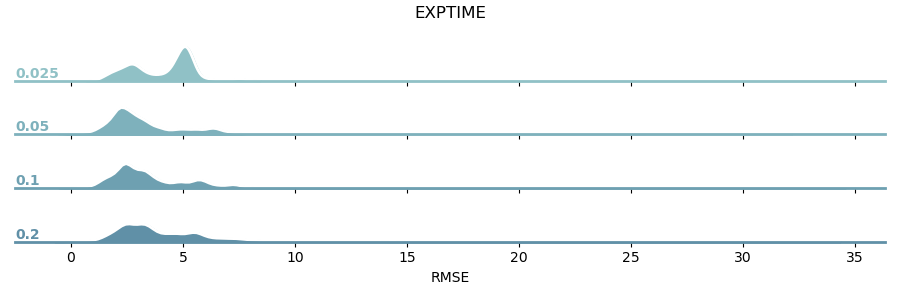

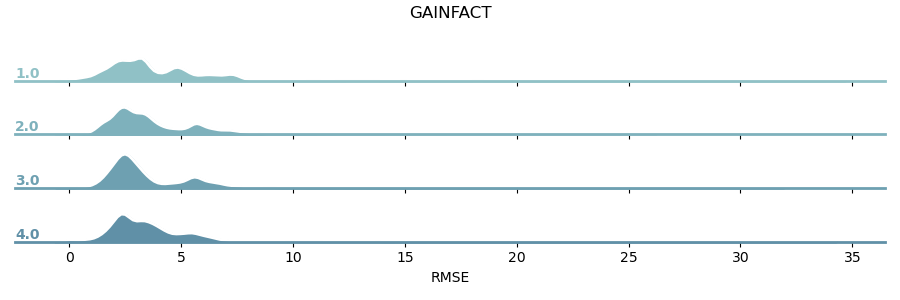

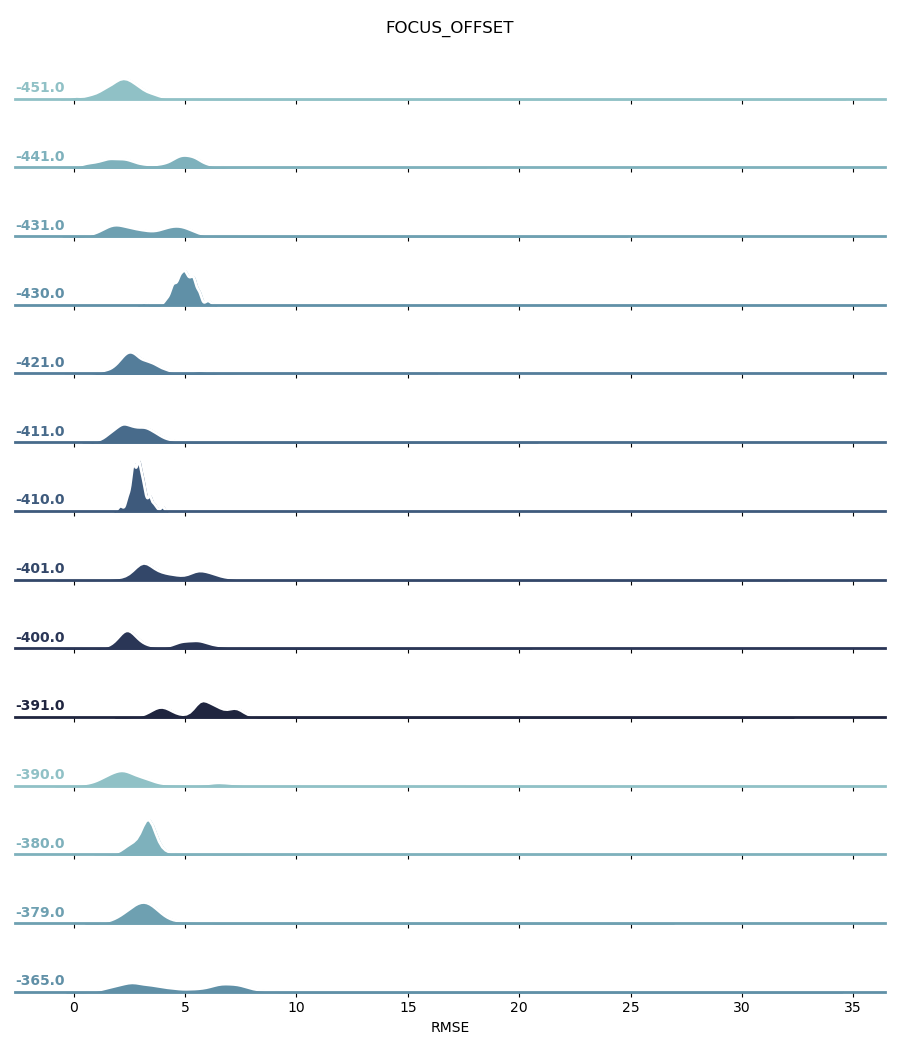

In [19]:
import seaborn as sns


def ridgeline(df, xkey, ykey):
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, np.round(float(label), 3), fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes)

    pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
    g = sns.FacetGrid(df, row=xkey, hue=xkey, aspect=12, height=.75, palette=pal)
    g.map(sns.kdeplot, ykey,
        bw_adjust=.5, clip_on=False,
        fill=True, alpha=1, linewidth=1.5)
    g.map(sns.kdeplot, ykey, clip_on=False, color="w", lw=2, bw_adjust=.5)
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)
    g.figure.subplots_adjust(hspace=-.25)
    g.map(label, xkey) 
    g.set(xlabel=ykey)
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)
    f = plt.gcf()
    f.suptitle(xkey)
    f.tight_layout()


df_day = img_table_solved.to_pandas()[daytime_float]
df_day['FOCUS_OFFSET'] = df_day['FOCUS'] - df_day['FOCUSMAX']

fig, ax = plt.subplots(figsize=(12,7))
ax.scatter(img_table_solved['N_STARS_MATCHED'][daytime_float], img_table_solved['RMSE'][daytime_float], s=30, alpha=0.2, color='limegreen', label='initial')
ax.scatter(img_table_solved['N_STARS_REMATCHED'][daytime_float], img_table_solved['RMSE'][daytime_float], s=30, marker='+', alpha=0.2, color='tomato', label='--verify')
ax.set_xlabel('N_STARS_MATCHED')
ax.set_ylabel('RMSE (arcsec)')
ax.set_xscale('log')
ax.legend()
fig.tight_layout()

fig, ax = plt.subplots(figsize=(12,7))
ax.plot(t[daytime_float], df_day['FOCUS'], marker='.', color='limegreen', alpha=0.5)
[ax.axvline(af_time, color='k', linestyle='--') for af_time in af_times]
ax.set_xlabel('TIMESTAMP (UTC)')
ax.set_ylabel('FOCUS POS')
fig.tight_layout()

ridgeline(df_day, 'EXPTIME', 'RMSE')
ridgeline(df_day, 'GAINFACT', 'RMSE')
ridgeline(df_day, 'FOCUS_OFFSET', 'RMSE')

All-up percentage of daytime images that were successfully solved.

In [20]:
pct_float_solved = 100 * np.nansum(img_table_solved['SOLVED'][daytime_float]) / np.nansum(img_table_solved['SOLVE_ATTEMPTED'][daytime_float])
pct_float_solved

<Quantity 96.57637095>

FOCUSMIN FOCUS FOCUSMAX GAINFACT  EXPTIME    UTC-SEC          UTC-USEC       CCDTEMP                           FILES                           SOLVE_ATTEMPTED SOLVED  FILESIZE      TIMESTAMP             RA                DEC            ORIENTATION        SCALE     N_STARS_FOUND N_STARS_MATCHED         RMSE         BKG_MED      BKG_MEAN      N_STARS_REMATCHED
                                     s          s                s            deg_C                                                                                                      s                deg                deg                deg         arcsec / pix                                      arcsec                                                    
-------- ----- -------- -------- --------- ------------ -------------------- ------- --------------------------------------------------------- --------------- ------ ---------- ----------------- ------------------ ------------------ ------------------ ------------ -------------

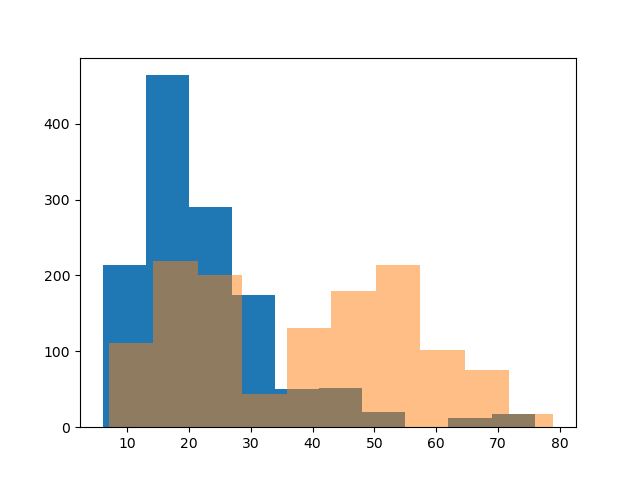

In [21]:
solved_daytime = (t_not_nans & default_gain & default_exp & daytime_float & (img_table_solved['SOLVED'] > 0))
# ra_match_daytime = np.abs(img_table_solved[daytime_float]['RA'] - 250.248*u.deg) < 1e-3*u.deg
# dec_match_daytime = np.abs(img_table_solved[daytime_float]['DEC'] - 45.008*u.deg) < 1e-3*u.deg
fig, ax = plt.subplots()
ax.hist(img_table_solved[solved_daytime]['N_STARS_MATCHED'])
ax.hist(img_table_solved[solved_daytime]['N_STARS_REMATCHED'], alpha=0.5)
img_table_solved[solved_daytime].pprint_all()